# Leave-One-Out Cross-Validation Approach

This notebook implements the Leave-One-Out Cross-Validation (LOOCV) evaluation strategy for the encoding circuit recommendation framework. Each classifier is evaluated independently across $N$ folds, with one dataset held out per fold.

**Inputs:** CSV files from `Quantum_Learning.ipynb` (complexity metrics + ground truth labels).

**Outputs:** LOOCV accuracy for Task-A and Task-B, per-metric and all-metrics comparisons, and inference results on 7 unseen test datasets.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 1. Setup

The same 14 meta-learners as the Majority Voting notebook are used: tree-based (DT, RF, Gradient Boosting, AdaBoost, Bagging), kernel-based (SVM with linear/RBF/sigmoid kernels), neural (MLP with two architectures), instance-based (kNN, NearestCentroid), probabilistic (NaiveBayes), and linear (LogisticRegression). SVM variants are configured with `probability=True` to support `predict_proba` for top-k inference.

In [2]:
CLASSIFIERS = {
    'DT': DecisionTreeClassifier(random_state=42),
    'RF': RandomForestClassifier(n_estimators=10, random_state=42),
    'Ensemble-GB': GradientBoostingClassifier(random_state=42),
    'Ensemble-AB': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42), 
        n_estimators=50, 
        random_state=42,
        algorithm='SAMME'
    ),
    'Ensemble-Bg': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=10,
        random_state=42
    ),
    'SVM-Linear': SVC(kernel='linear', random_state=42, probability=True),
    'SVM-RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True),
    'SVM-Sigmoid': SVC(kernel='sigmoid', C=1.0, gamma='scale', random_state=42, probability=True),
    'MLP-500': MLPClassifier(hidden_layer_sizes=(500,), max_iter=1000, random_state=42),
    'MLP-100-100-100': MLPClassifier(hidden_layer_sizes=(100,100,100), max_iter=1000, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'NearestCentroid': NearestCentroid(),
    'NaiveBayes': GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
}

print(f"Classifiers: {len(CLASSIFIERS)}")

Classifiers: 14


## 2. Data Loading

Load the synthesis DataFrame (24 complexity metrics per dataset) and ground truth labels for both task formulations:
- **Task-A**: single best encoding circuit per dataset
- **Task-B**: all encoding circuits within a tolerance threshold of the best accuracy

In [3]:
print("="*70)
print("LOAD DATA")
print("="*70)

df = pd.read_csv("results/synthesis_df.csv", index_col=0)
df_tied = pd.read_csv("results/taskb_labels.csv")
df_tied = df_tied.set_index('Dataset')

metric_columns = [c for c in df.columns if c != 'Best_Kernel']

print(f"Datasets: {len(df)}")
print(f"Metrics: {len(metric_columns)}")
print(f"Task-A samples: {len(df)}")
print(f"Task-B samples: {len(df_tied)}")

LOAD DATA
Datasets: 200
Metrics: 24
Task-A samples: 200
Task-B samples: 442


## 3. Core Functions

### 3.1 Task-A Evaluation

For each fold, one dataset is held out as the test sample. The classifier trains on the remaining $N-1$ datasets and predicts a single encoding circuit. A prediction is correct only when it matches the unique best label for the held-out dataset.

In [4]:
def evaluate_taska(X, y, classifiers, scale_features=True, desc="Task-A"):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    loo = LeaveOneOut()
    results = {}
    
    for clf_name, clf in tqdm(classifiers.items(), desc=desc):
        scores = []
        
        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
            
            if scale_features:
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)
            
            try:
                clf_clone = clf.__class__(**clf.get_params())
                clf_clone.fit(X_train, y_train)
                pred = clf_clone.predict(X_test)
                scores.append(1 if pred[0] == y_test[0] else 0)
            except:
                scores.append(0)
        
        results[clf_name] = {
            'accuracy': np.mean(scores),
            'std': np.std(scores),
            'correct': sum(scores),
            'total': len(scores)
        }
    
    return results

### 3.2 Task-B Evaluation

For each fold, the training set is expanded: each remaining dataset contributes one sample per tied-best encoding circuit, all sharing the same feature vector. A prediction is correct when it falls within the set of valid circuits for the held-out dataset. The `LabelEncoder` is refit per fold because the label space may shift when removing the test dataset.

In [5]:
def evaluate_taskb(X, df_tied, dataset_names, classifiers, scale_features=True, desc="Task-B"):
    n_datasets = len(dataset_names)
    
    valid_kernels_lookup = {}
    for dataset in dataset_names:
        valid_kernels_lookup[dataset] = df_tied.loc[
            df_tied.index == dataset, 'Best_Kernel'
        ].tolist()
    
    results = {}
    
    for clf_name, clf in tqdm(classifiers.items(), desc=desc):
        scores = []
        
        for test_idx, test_dataset in enumerate(dataset_names):
            X_train_list = []
            y_train_list = []
            
            for train_idx, train_dataset in enumerate(dataset_names):
                if train_dataset == test_dataset:
                    continue
                
                valid_kernels = valid_kernels_lookup[train_dataset]
                for kernel in valid_kernels:
                    X_train_list.append(X[train_idx])
                    y_train_list.append(kernel)
            
            X_train = np.array(X_train_list)
            y_train = np.array(y_train_list)
            
            # Encode
            le = LabelEncoder()
            y_train_encoded = le.fit_transform(y_train)
            
            if len(np.unique(y_train_encoded)) < 2:
                scores.append(0)
                continue
            
            if scale_features:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X[test_idx:test_idx+1])
            else:
                X_train_scaled = X_train
                X_test_scaled = X[test_idx:test_idx+1]
            
            valid_kernels_test = valid_kernels_lookup[test_dataset]
            
            try:
                clf_clone = clf.__class__(**clf.get_params())
                clf_clone.fit(X_train_scaled, y_train_encoded)
                pred_encoded = clf_clone.predict(X_test_scaled)
                pred_kernel = le.inverse_transform(pred_encoded)[0]
                
                is_correct = pred_kernel in valid_kernels_test
                scores.append(1 if is_correct else 0)
            except:
                scores.append(0)
        
        results[clf_name] = {
            'accuracy': np.mean(scores),
            'std': np.std(scores),
            'correct': sum(scores),
            'total': n_datasets
        }
    
    return results

In [6]:
dataset_names = df.index.tolist()
y = df['Best_Kernel'].values
X_all = df[metric_columns].values  

all_results = {}

In [7]:
print(metric_columns)

['f1', 'f1v', 'f2', 'f3', 'f4', 'l1', 'l2', 'l3', 'n1', 'n2', 'n3', 'n4', 't1', 'lsc', 'density', 'clsCoef', 'hubs', 't2', 't3', 't4', 'c1', 'c2', 'kolmogorov', 'intrinsic']


## 4. Task-A: Single-Best Recommendation

### 4.1 Single Metric Evaluation

Each of the 24 complexity metrics is evaluated independently as the sole input feature, paired with each of the 14 classifiers. The best (metric, classifier) pair is reported.

In [8]:
print("\n" + "="*70)
print("CASE 1: SINGLE METRIC - TASK-A")
print("="*70)

single_metric_taska = []

for metric in tqdm(metric_columns, desc="Single Metric Task-A"):
    X_single = df[[metric]].values
    results = evaluate_taska(X_single, y, CLASSIFIERS, scale_features=True, desc="")
    
    for clf_name, res in results.items():
        single_metric_taska.append({
            'Metric': metric,
            'Classifier': clf_name,
            'Accuracy': res['accuracy'],
            'Correct': res['correct'],
            'Total': res['total']
        })

df_a_single = pd.DataFrame(single_metric_taska)
best_single_a = df_a_single.loc[df_a_single['Accuracy'].idxmax()]
print(f"\n Best Single Metric (Task-A): {best_single_a['Metric']} + {best_single_a['Classifier']} = {best_single_a['Accuracy']:.4f}")

all_results['single_metric_taska'] = df_a_single


CASE 1: SINGLE METRIC - TASK-A


Single Metric Task-A: 100%|██████████| 24/24 [1:53:21<00:00, 283.41s/it]


 Best Single Metric (Task-A): n4 + MLP-500 = 0.5850


### 4.2 All Metrics Evaluation

All 24 metrics used jointly as the feature vector, paired with each of the 14 classifiers.

In [9]:
print("\n" + "="*70)
print("CASE 3: ALL METRICS (24) - TASK-A")
print("="*70)

results_all_a = evaluate_taska(X_all, y, CLASSIFIERS, scale_features=True, desc="All Metrics Task 1-A")

all_metrics_taska = []
for clf_name, res in results_all_a.items():
    all_metrics_taska.append({
        'Classifier': clf_name,
        'Accuracy': res['accuracy'],
        'Correct': res['correct'],
        'Total': res['total']
    })

df_a_all = pd.DataFrame(all_metrics_taska).sort_values('Accuracy', ascending=False)
best_all_a = df_a_all.iloc[0]
print(f"\n Best All Metrics (Task-A): {best_all_a['Classifier']} = {best_all_a['Accuracy']:.4f}")

all_results['all_metrics_taska'] = df_a_all


CASE 3: ALL METRICS (24) - TASK-A


All Metrics Task 1-A: 100%|██████████| 14/14 [07:44<00:00, 33.16s/it]


 Best All Metrics (Task-A): SVM-Linear = 0.6900


## 5. Task-B: Tolerance-Based Recommendation

### 5.1 Single Metric Evaluation

Same procedure as Section 4.1, but using the Task-B evaluation mechanism: a prediction is counted as correct if it belongs to the set of valid encoding circuits for that dataset.

In [10]:
print("\n" + "="*70)
print("CASE 2: SINGLE METRIC - TASK-B")
print("="*70)

single_metric_taskb = []

for metric in tqdm(metric_columns, desc="Single Metric Task-B"):
    X_single = df[[metric]].values
    results = evaluate_taskb(X_single, df_tied, dataset_names, CLASSIFIERS, scale_features=True, desc="")
    
    for clf_name, res in results.items():
        single_metric_taskb.append({
            'Metric': metric,
            'Classifier': clf_name,
            'Accuracy': res['accuracy'],
            'Correct': res['correct'],
            'Total': res['total']
        })

df_b_single = pd.DataFrame(single_metric_taskb)
best_single_name = df_b_single.iloc[0]['Metric']
best_single_b = df_b_single.loc[df_b_single['Accuracy'].idxmax()]
print(f"\n Best Single Metric (Task-B): {best_single_b['Metric']} + {best_single_b['Classifier']} = {best_single_b['Accuracy']:.4f}")

all_results['single_metric_taskb'] = df_b_single


CASE 2: SINGLE METRIC - TASK-B


Single Metric Task-B: 100%|██████████| 24/24 [1:15:10<00:00, 187.94s/it]


 Best Single Metric (Task-B): n4 + Ensemble-GB = 0.7650


### 5.2 All Metrics Evaluation

Same procedure as Section 4.2, but with tolerance-based accuracy evaluation.

In [11]:
print("\n" + "="*70)
print("CASE 4: ALL METRICS (24) - TASK-B")
print("="*70)

results_all_b = evaluate_taskb(X_all, df_tied, dataset_names, CLASSIFIERS, scale_features=True, desc="All Metrics Task 1-B")

all_metrics_taskb = []
for clf_name, res in results_all_b.items():
    all_metrics_taskb.append({
        'Classifier': clf_name,
        'Accuracy': res['accuracy'],
        'Correct': res['correct'],
        'Total': res['total']
    })

df_b_all = pd.DataFrame(all_metrics_taskb).sort_values('Accuracy', ascending=False)
best_all_b = df_b_all.iloc[0]
print(f"\n Best All Metrics (Task-B): {best_all_b['Classifier']} = {best_all_b['Accuracy']:.4f}")

all_results['all_metrics_taskb'] = df_b_all


CASE 4: ALL METRICS (24) - TASK-B


All Metrics Task 1-B: 100%|██████████| 14/14 [06:24<00:00, 27.48s/it]


 Best All Metrics (Task-B): RF = 0.8550


## 6. Results Summary

### 6.1 Aggregate and Save

For each metric, the classifier achieving the highest accuracy is retained. The all-metrics row is appended for direct comparison. Results are saved to CSV for downstream plotting and paper tables.

In [12]:
best_per_metric_a = (
    df_a_single
    .sort_values('Accuracy', ascending=False)
    .drop_duplicates(subset='Metric', keep='first')
    .rename(columns={'Accuracy': 'Mean_Acc'})
)
best_per_metric_a['Std_Acc'] = 0.0

best_all_a = df_a_all.sort_values('Accuracy', ascending=False).iloc[0]
all_row_a = pd.DataFrame([{
    'Metric': 'ALL_METRICS',
    'Classifier': best_all_a['Classifier'],
    'Mean_Acc': best_all_a['Accuracy'],
    'Std_Acc': 0.0,
    'Correct': best_all_a['Correct'],
    'Total': best_all_a['Total']
}])
loocv_a = pd.concat([best_per_metric_a, all_row_a], ignore_index=True)
loocv_a = loocv_a.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)

best_per_metric_b = (
    df_b_single
    .sort_values('Accuracy', ascending=False)
    .drop_duplicates(subset='Metric', keep='first')
    .rename(columns={'Accuracy': 'Mean_Acc'})
)
best_per_metric_b['Std_Acc'] = 0.0

best_all_b = df_b_all.sort_values('Accuracy', ascending=False).iloc[0]
all_row_b = pd.DataFrame([{
    'Metric': 'ALL_METRICS',
    'Classifier': best_all_b['Classifier'],
    'Mean_Acc': best_all_b['Accuracy'],
    'Std_Acc': 0.0,
    'Correct': best_all_b['Correct'],
    'Total': best_all_b['Total']
}])
loocv_b = pd.concat([best_per_metric_b, all_row_b], ignore_index=True)
loocv_b = loocv_b.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)

# ── Save ─────────────────────────────────────────────────────
loocv_a.to_csv("results/loocv_taska_results.csv", index=False)
loocv_b.to_csv("results/loocv_taskb_results.csv", index=False)

print("Saved:")
print(f"  results/loocv_taska_results.csv  ({len(loocv_a)} rows)")
print(f"  results/loocv_taskb_results.csv  ({len(loocv_b)} rows)")
print()
print("Task-A LOOCV preview:")
print(loocv_a[['Metric', 'Classifier', 'Mean_Acc']].to_string(index=False))
print()
print("Task-B LOOCV preview:")
print(loocv_b[['Metric', 'Classifier', 'Mean_Acc']].to_string(index=False))

Saved:
  results/loocv_taska_results.csv  (25 rows)
  results/loocv_taskb_results.csv  (25 rows)

Task-A LOOCV preview:
     Metric         Classifier  Mean_Acc
ALL_METRICS         SVM-Linear     0.690
         n4            MLP-500     0.585
    density            MLP-500     0.570
         f2    MLP-100-100-100     0.560
         f1    MLP-100-100-100     0.550
        f1v    MLP-100-100-100     0.545
         l2    MLP-100-100-100     0.520
        lsc            SVM-RBF     0.515
         f4            MLP-500     0.515
         l1            MLP-500     0.505
         t1 LogisticRegression     0.490
         f3    MLP-100-100-100     0.485
         n2            SVM-RBF     0.480
         c2    MLP-100-100-100     0.475
  intrinsic            MLP-500     0.475
         c1        Ensemble-GB     0.470
         n1            SVM-RBF     0.460
       hubs            MLP-500     0.460
         l3            SVM-RBF     0.450
         n3            MLP-500     0.405
         t4        

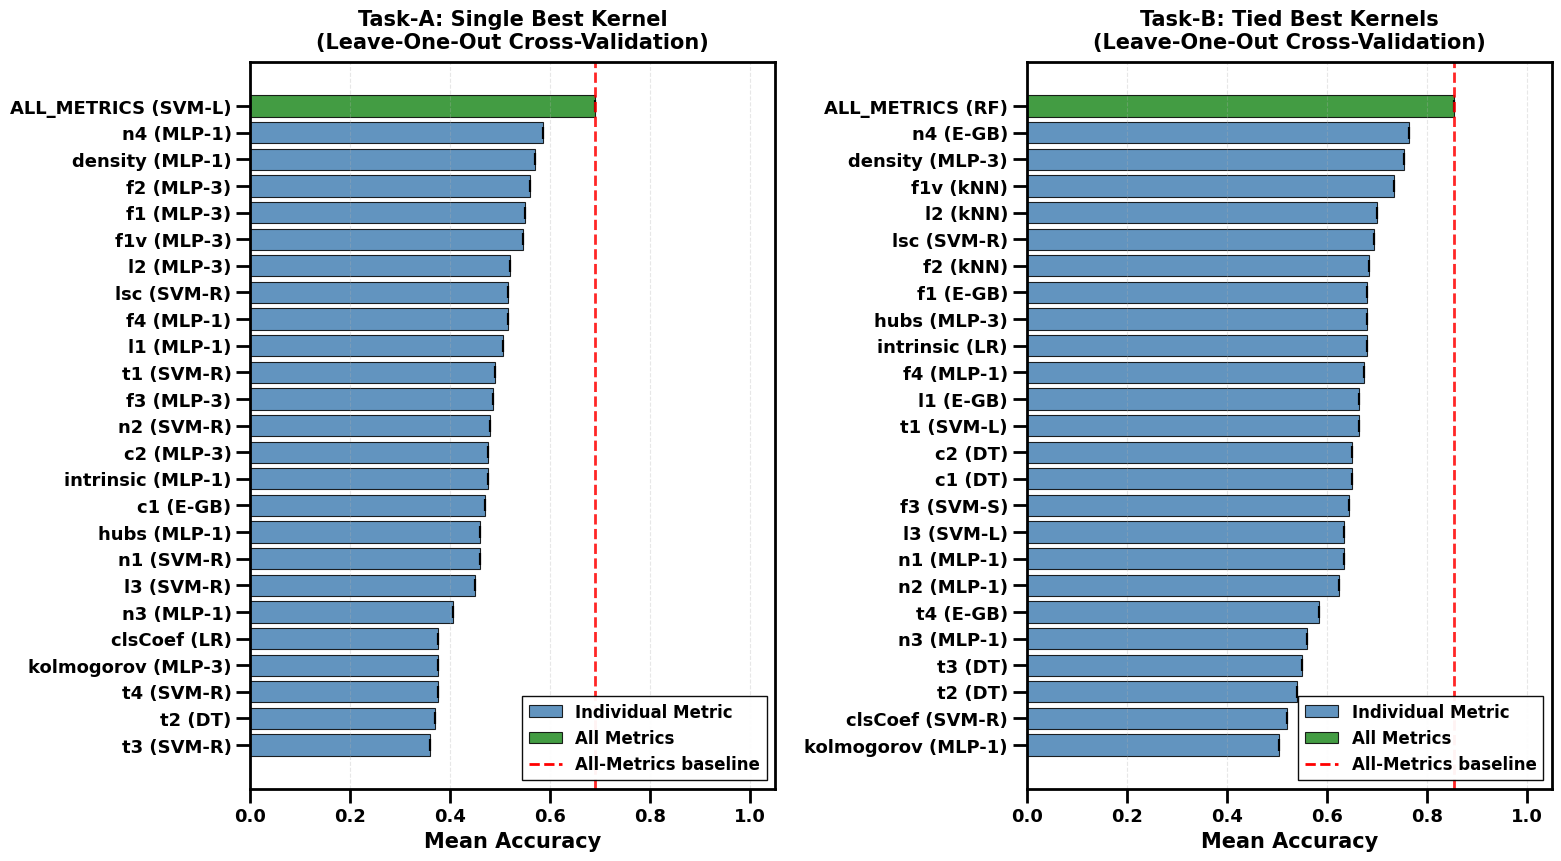


SUMMARY (Best Config per Metric)

Task-A:
  Best Single: n4 + MLP-500 = 0.5850
  ALL_METRICS: SVM-Linear = 0.6900

Task-B:
  Best Single: n4 + Ensemble-GB = 0.7650
  ALL_METRICS: RF = 0.8550


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_a_plot = df_a_single.loc[
    df_a_single.groupby('Metric')['Accuracy'].idxmax()
].copy().reset_index(drop=True)
df_a_plot['Mean_Acc'] = df_a_plot['Accuracy']
df_a_plot['Std_Acc']  = 0.0

df_b_plot = df_b_single.loc[
    df_b_single.groupby('Metric')['Accuracy'].idxmax()
].copy().reset_index(drop=True)
df_b_plot['Mean_Acc'] = df_b_plot['Accuracy']
df_b_plot['Std_Acc']  = 0.0

best_all_a = df_a_all.loc[df_a_all['Accuracy'].idxmax()]
best_all_b = df_b_all.loc[df_b_all['Accuracy'].idxmax()]

all_row_a = pd.DataFrame([{
    'Metric':     'ALL_METRICS',
    'Classifier': best_all_a['Classifier'],
    'Mean_Acc':   best_all_a['Accuracy'],
    'Std_Acc':    0.0
}])

all_row_b = pd.DataFrame([{
    'Metric':     'ALL_METRICS',
    'Classifier': best_all_b['Classifier'],
    'Mean_Acc':   best_all_b['Accuracy'],
    'Std_Acc':    0.0
}])

df_a_plot = pd.concat([df_a_plot, all_row_a], ignore_index=True)
df_b_plot = pd.concat([df_b_plot, all_row_b], ignore_index=True)

df_a_plot = df_a_plot.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)
df_b_plot = df_b_plot.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)

all_metrics_a = {'Mean_Acc': best_all_a['Accuracy']}
all_metrics_b = {'Mean_Acc': best_all_b['Accuracy']}

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.linewidth': 2.0,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size': 10,
    'ytick.major.size': 10,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

COLOR_SINGLE = 'steelblue'
COLOR_ALL    = 'forestgreen'

ABBREV_CLF = {
    'LogisticRegression': 'LR',
    'SVM-Linear': 'SVM-L',
    'SVM-Sigmoid': 'SVM-S',
    'SVM-RBF': 'SVM-R',
    'MLP-100-100-100': 'MLP-3',
    'MLP-500': 'MLP-1',
    'DT': 'DT',
    'NaiveBayes': 'NB',
    'kNN': 'kNN',
    'Ensemble-GB': 'E-GB',
}

def plot_panel(ax, df_plot, all_metrics_row, title):
    colors = [COLOR_ALL if m == 'ALL_METRICS' else COLOR_SINGLE
              for m in df_plot['Metric']]

    ax.barh(
        range(len(df_plot)),
        df_plot['Mean_Acc'],
        xerr=df_plot['Std_Acc'],
        color=colors,
        capsize=4,
        alpha=0.85,
        edgecolor='black',
        linewidth=0.8,
        error_kw=dict(elinewidth=1.5, ecolor='black', capthick=1.5)
    )

    ax.set_yticks(range(len(df_plot)))

    ylabels = [
        f"{row['Metric']} ({ABBREV_CLF.get(row['Classifier'], row['Classifier'])})"
        for _, row in df_plot.iterrows()
    ]
    ax.set_yticklabels(ylabels, fontweight='bold')   # fontsize theo rcParams (13)

    ax.set_xlabel('Mean Accuracy', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=10)

    ax.axvline(
        x=all_metrics_row['Mean_Acc'],
        color='red', linestyle='--', linewidth=2.0,
        alpha=0.85, label='_nolegend_'
    )

    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)   

    patch_single = mpatches.Patch(
        facecolor=COLOR_SINGLE, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='Individual Metric'
    )
    patch_all = mpatches.Patch(
        facecolor=COLOR_ALL, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='All Metrics'
    )
    line_ref = plt.Line2D(
        [], [], color='red', linestyle='--', linewidth=2.0,
        label='All-Metrics baseline'
    )
    ax.legend(
        handles=[patch_single, patch_all, line_ref],
        loc='lower right',
        framealpha=0.95,
        edgecolor='black',
        fancybox=False,
        fontsize=12
    )

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

    ax.grid(axis='x', alpha=0.3, linestyle='--')

fig, axes = plt.subplots(1, 2, figsize=(16, 9))   

plot_panel(axes[0], df_a_plot, all_metrics_a,
           'Task-A: Single Best Kernel\n(Leave-One-Out Cross-Validation)')

plot_panel(axes[1], df_b_plot, all_metrics_b,
           'Task-B: Tied Best Kernels\n(Leave-One-Out Cross-Validation)')

plt.tight_layout(pad=1.5)  
plt.savefig('results/loocv_single_vs_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("SUMMARY (Best Config per Metric)")
print("=" * 70)

for task, df_plot, best_all in [
    ("Task-A", df_a_plot, best_all_a),
    ("Task-B", df_b_plot, best_all_b),
]:
    best_single = df_plot[df_plot['Metric'] != 'ALL_METRICS'].iloc[0]
    print(f"\n{task}:")
    print(f"  Best Single: {best_single['Metric']} + {best_single['Classifier']} = {best_single['Mean_Acc']:.4f}")
    print(f"  ALL_METRICS: {best_all['Classifier']} = {best_all['Accuracy']:.4f}")

print("=" * 70)

In [14]:
print("Type of best_single_a:", type(best_single_a))
print("best_single_a:\n", best_single_a)
print("Index:", best_single_a.index.tolist() if hasattr(best_single_a, 'index') else 'N/A')

Type of best_single_a: <class 'pandas.core.series.Series'>
best_single_a:
 Metric             n4
Classifier    MLP-500
Accuracy        0.585
Correct           117
Total             200
Name: 162, dtype: object
Index: ['Metric', 'Classifier', 'Accuracy', 'Correct', 'Total']


In [15]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

def get_acc(series):
    if 'Best_Acc' in series.index:
        return series['Best_Acc']
    elif 'Accuracy' in series.index:
        return series['Accuracy']
    else:
        raise KeyError(f"No accuracy column found. Available: {series.index.tolist()}")

summary_data = [
    {
        'Case': 'Single Metric',
        'Task': 'Task-A',
        'Best_Config': f"{best_single_a['Metric']} + {best_single_a['Classifier']}",
        'Accuracy': get_acc(best_single_a)
    },
    {
        'Case': 'Single Metric',
        'Task': 'Task-B',
        'Best_Config': f"{best_single_b['Metric']} + {best_single_b['Classifier']}",
        'Accuracy': get_acc(best_single_b)
    },
    {
        'Case': 'All Metrics (24)',
        'Task': 'Task-A',
        'Best_Config': best_all_a['Classifier'],
        'Accuracy': get_acc(best_all_a)
    },
    {
        'Case': 'All Metrics (24)',
        'Task': 'Task-B',
        'Best_Config': best_all_b['Classifier'],
        'Accuracy': get_acc(best_all_b)
    },
]

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "-"*70)
print("PIVOT TABLE:")
print("-"*70)
pivot = summary_df.pivot(index='Case', columns='Task', values='Accuracy')
print(pivot)


SUMMARY

            Case   Task      Best_Config  Accuracy
   Single Metric Task-A     n4 + MLP-500     0.585
   Single Metric Task-B n4 + Ensemble-GB     0.765
All Metrics (24) Task-A       SVM-Linear     0.690
All Metrics (24) Task-B               RF     0.855

----------------------------------------------------------------------
PIVOT TABLE:
----------------------------------------------------------------------
Task              Task-A  Task-B
Case                            
All Metrics (24)   0.690   0.855
Single Metric      0.585   0.765


## 7. Inference on Unseen Datasets

### 7.1 Train Final Models

Train two final models on the entire Task-B dataset (no holdout) for inference: one using all 24 metrics, one using only the single best metric from Section 5.1. Unlike Majority Voting which trains all 14 classifiers, LOOCV uses only the single best classifier per configuration. Scalers are returned alongside the models to ensure consistent preprocessing at inference time.

In [16]:
from sklearn.base import clone

def train_taskb_models(best_single_metric, best_single_clf, best_all_clf):
    scaler_all = StandardScaler()
    X_scaled = scaler_all.fit_transform(X_all)
    
    X_train_single, X_train_all, y_train_list = [], [], []
    
    for idx, ds_name in enumerate(dataset_names):
        valid_kernels = df_tied.loc[df_tied.index == ds_name, 'Best_Kernel'].tolist()
        for kernel in valid_kernels:
            X_train_single.append([df.loc[ds_name, best_single_metric]])
            X_train_all.append(X_scaled[idx])
            y_train_list.append(kernel)
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_train_list)
    
    X_train_single = np.array(X_train_single)
    scaler_single = StandardScaler()
    X_train_single_scaled = scaler_single.fit_transform(X_train_single)
    
    model_all = clone(CLASSIFIERS[best_all_clf])
    if isinstance(model_all, SVC):
        model_all.set_params(probability=True)
    model_all.fit(np.array(X_train_all), y_encoded)
    
    model_single = clone(CLASSIFIERS[best_single_clf])
    if isinstance(model_single, SVC):
        model_single.set_params(probability=True)
    model_single.fit(X_train_single_scaled, y_encoded)
    
    return {
        'single': {
            'model': model_single,
            'scaler': scaler_single,          
            'feature': best_single_metric,
            'classifier': best_single_clf
        },
        'all': {
            'model': model_all,
            'scaler': scaler_all,
            'classifier': best_all_clf
        },
        'encoder': le
    }

print("=" * 70)
print("TRAIN TASK-B MODELS (Using Best Configurations)")
print("=" * 70)
print(f"\n  Single Metric: {best_single_b['Metric']} + {best_single_b['Classifier']}")
print(f"  All Metrics:   24 features + {best_all_b['Classifier']}")

trained_models = train_taskb_models(
    best_single_metric=best_single_b['Metric'],
    best_single_clf=best_single_b['Classifier'],
    best_all_clf=best_all_b['Classifier']
)

print(f"\n Trained models successfully")

print(f"has predict_proba (all):    {hasattr(trained_models['all']['model'], 'predict_proba')}")
print(f"has predict_proba (single): {hasattr(trained_models['single']['model'], 'predict_proba')}")

TRAIN TASK-B MODELS (Using Best Configurations)

  Single Metric: n4 + Ensemble-GB
  All Metrics:   24 features + RF

 Trained models successfully
has predict_proba (all):    True
has predict_proba (single): True


### 7.2 Inference Utilities

Two helper functions used in the inference pipeline. **`compute_ground_truth`** derives the ground-truth label set per test dataset from the exhaustive evaluation: for each dataset, the encoding circuits achieving the maximum accuracy across all quantum-kernel classifiers form the ground-truth set. **`get_top_k_predictions_ensemble`** ranks encoding circuits by the trained model's predicted probabilities and returns the top-$k$ candidates. When multiple models are provided, their probability vectors are summed before ranking; classifiers without `predict_proba` fall back to a one-hot vote.

In [17]:
from src.config import *
from src.kernel_evaluation import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [18]:
def compute_ground_truth(df_all_results):
    ground_truth = {}
    
    for ds_name, ds_group in df_all_results.groupby('Dataset'):
        kernel_best = ds_group.groupby('Kernel')['Mean_Acc'].max()
        
        global_best_acc = kernel_best.max()
        
        best_kernels = kernel_best[kernel_best == global_best_acc].index.tolist()
        
        ground_truth[ds_name] = best_kernels
    
    return ground_truth

from collections import Counter

def get_top_k_predictions_ensemble(X_scaled, trained_models, label_encoder, top_k=3):
    proba_sum = None

    for name, model in trained_models.items():
        try:
            if hasattr(model, 'predict_proba'):
                proba = model.predict_proba(X_scaled)[0]
            else:
                # Fallback: one-hot encode prediction
                pred = model.predict(X_scaled)[0]
                proba = np.zeros(len(label_encoder.classes_))
                proba[pred] = 1.0

            if proba_sum is None:
                proba_sum = proba
            else:
                proba_sum += proba
        except Exception:
            pass

    if proba_sum is None:
        return []

    top_k_indices = np.argsort(proba_sum)[::-1][:top_k]
    kernel_proba = [
        (str(label_encoder.inverse_transform([idx])[0]), proba_sum[idx] / proba_sum.sum())
        for idx in top_k_indices
    ]
    return kernel_proba

### 7.3 Test Dataset Preparation

7 new datasets with varying characteristics (linearly separable, non-linear, high-dimensional, imbalanced) for out-of-sample validation. All are normalized to $[0, 1]$ and reduced to at most 4 features via PCA.

In [19]:
from sklearn.datasets import load_digits, make_moons, make_circles, make_classification
from sklearn.datasets import make_gaussian_quantiles
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

def prepare_dataset(X, y, name, max_features=4):
    scaler_prep = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler_prep.fit_transform(X)
    if X_scaled.shape[1] > max_features:
        pca = PCA(n_components=max_features)
        X_scaled = pca.fit_transform(X_scaled)
        print(f"  {name}: {X.shape} → PCA → {X_scaled.shape} ({pca.explained_variance_ratio_.sum():.1%} var)")
    else:
        print(f"  {name}: {X_scaled.shape}")
    return X_scaled, y

print("=" * 70)
print("PREPARE ALL 7 TEST DATASETS")
print("=" * 70)

digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X_digits, y_digits = prepare_dataset(digits.data[mask], digits.target[mask], "Digits_0v1")

X_moons, y_moons = make_moons(n_samples=200, noise=0.35, random_state=42)
X_moons, y_moons = prepare_dataset(X_moons, y_moons, "Moons_n35")

X_circles, y_circles = make_circles(n_samples=200, noise=0.30, factor=0.3, random_state=42)
X_circles, y_circles = prepare_dataset(X_circles, y_circles, "Circles")

X_synth, y_synth = make_classification(
    n_samples=200, n_features=4, n_informative=3,
    n_redundant=1, flip_y=0.1, random_state=42
)
X_synth, y_synth = prepare_dataset(X_synth, y_synth, "Synthetic")

X_gauss, y_gauss = make_gaussian_quantiles(
    n_samples=150, n_features=3, n_classes=2, random_state=42
)
X_gauss, y_gauss = prepare_dataset(X_gauss, y_gauss, "GaussianQuantiles")

np.random.seed(42)
n_per_ring = 50
X_rings, y_rings = [], []
for i, r in enumerate([0.3, 0.6, 0.9]):
    theta = np.random.uniform(0, 2*np.pi, n_per_ring)
    X_ring = np.column_stack([r*np.cos(theta), r*np.sin(theta)])
    X_ring += np.random.normal(0, 0.03, X_ring.shape)
    X_rings.append(X_ring)
    y_rings.extend([i % 2] * n_per_ring)
X_multiring = np.vstack(X_rings)
y_multiring = np.array(y_rings)
X_multiring, y_multiring = prepare_dataset(X_multiring, y_multiring, "MultiRing")

X_imbal, y_imbal = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    weights=[0.8, 0.2], class_sep=1.5, random_state=42
)
X_imbal, y_imbal = prepare_dataset(X_imbal, y_imbal, "Imbalanced")

all_test_datasets = {
    'Digits_0v1':        (X_digits,    y_digits),
    'Moons_n35':         (X_moons,     y_moons),
    'Circles':           (X_circles,   y_circles),
    'Synthetic':         (X_synth,     y_synth),
    'GaussianQuantiles': (X_gauss,     y_gauss),
    'MultiRing':         (X_multiring, y_multiring),
    'Imbalanced':        (X_imbal,     y_imbal),
}

print(f"\n Prepared {len(all_test_datasets)} test datasets")


PREPARE ALL 7 TEST DATASETS
  Digits_0v1: (360, 64) → PCA → (360, 4) (71.6% var)
  Moons_n35: (200, 2)
  Circles: (200, 2)
  Synthetic: (200, 4)
  GaussianQuantiles: (150, 3)
  MultiRing: (150, 2)
  Imbalanced: (100, 2)

 Prepared 7 test datasets


### 7.4 Complexity Metrics for Test Datasets

Compute the 24 complexity metrics for each test dataset, averaged over 10 runs to reduce stochastic variance. This produces the input feature matrix for prediction.

In [ ]:
import problexity as px
from Qsun.Qdata import *
TEST_SIZE = 0.2
N_RUNS = 10
RANDOM_STATE = 42

METRIC_NAMES = [
    'f1', 'f1v', 'f2', 'f3', 'f4', 'l1', 'l2', 'l3',
    'n1', 'n2', 'n3', 'n4', 't1', 'lsc', 'density',
    'clsCoef', 'hubs', 't2', 't3', 't4', 'c1', 'c2',
    'kolmogorov', 'intrinsic'
]

print("\n" + "=" * 70)
print(f"{'Dataset':<20} {'Samples':>8} {'Features':>10} {'Class 0':>8} {'Class 1':>8} {'Balance':>8}")
print("-" * 70)

for name, (X, y) in all_test_datasets.items():
    cls = np.bincount(y)
    bal = min(cls) / max(cls)
    print(f"{name:<20} {len(y):>8} {X.shape[1]:>10} {cls[0]:>8} {cls[1]:>8} {bal:>8.2f}")

print("=" * 70)
print("\n" + "=" * 70)
print("COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS")
print("=" * 70)

complexities_test = {}

for name, (X, y) in all_test_datasets.items():
    print(f"\n  {name}: shape={X.shape}")
    
    complexities_runs = []
    for i in range(N_RUNS):
        seed = 42 + i
        
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=y
        )
        
        scaler = MinMaxScaler(feature_range=(0, 1))
        X_tr = scaler.fit_transform(X_tr)
        
        cc = px.ComplexityCalculator()
        cc.fit(X_tr, y_tr)
        results = list(cc.complexity)
        results.append(kolmogorov_complex(X_tr)['best_bytes'])
        results.append(intrinsic_dim_from_cov(X_tr))
        complexities_runs.append(results)
    
    complexities_runs = np.array(complexities_runs)
    complexities_test[name] = np.mean(complexities_runs, axis=0)
    print(f"     Computed {len(METRIC_NAMES)} metrics")

df_all_test_complexity = pd.DataFrame(complexities_test, index=METRIC_NAMES).T
print(f"\n Complexity matrix: {df_all_test_complexity.shape}")
print(df_all_test_complexity.round(4).to_string())


Dataset               Samples   Features  Class 0  Class 1  Balance
----------------------------------------------------------------------
Digits_0v1                360          4      178      182     0.98
Moons_n35                 200          2      100      100     1.00
Circles                   200          2      100      100     1.00
Synthetic                 200          4      103       97     0.94
GaussianQuantiles         150          3       75       75     1.00
MultiRing                 150          2      100       50     0.50
Imbalanced                100          2       80       20     0.25

COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS

  Digits_0v1: shape=(360, 4)
     Computed 24 metrics

  Moons_n35: shape=(200, 2)
     Computed 24 metrics

  Circles: shape=(200, 2)
     Computed 24 metrics

  Synthetic: shape=(200, 4)
     Computed 24 metrics

  GaussianQuantiles: shape=(150, 3)
     Computed 24 metrics

  MultiRing: shape=(150, 2)
     Computed 24 metrics



In [ ]:
trained_models = train_taskb_models(
    best_single_metric=best_single_b['Metric'],
    best_single_clf=best_single_b['Classifier'],
    best_all_clf=best_all_b['Classifier']
)
print(f"\n Trained models successfully")

BEST_SINGLE_METRIC = best_single_b['Metric']
feature_cols       = metric_columns  

scaler_b_final          = trained_models['all']['scaler']
scaler_b_single         = trained_models['single']['scaler']   
trained_models_b_final  = {'LOO_All': trained_models['all']['model']}
trained_models_b_single = {'LOO_Single': trained_models['single']['model']}
le_b                    = trained_models['encoder']


✓ Trained models successfully


### 7.5 Ground Truth: Exhaustive Evaluation

Brute-force evaluation of all 9 encoding circuits × 3 quantum-kernel classifiers × 10 random splits on each test dataset. This establishes the true best encoding circuit(s) for comparison against predictions.

In [24]:
N_VERIFY_RUNS = 10
ML_MODELS = list(MODEL_REGISTER.keys())

print("\n" + "=" * 70)
print(f"GROUND TRUTH: ALL KERNELS × ALL MODELS ({N_VERIFY_RUNS} runs)")
print("=" * 70)

all_results_7 = []

for ds_name, (X, y) in all_test_datasets.items():
    print(f"\n{'='*70}\n  {ds_name}\n{'='*70}")
    
    kernel_model_scores = {k: {m: [] for m in ML_MODELS} for k in ENCODING_REGISTER.keys()}
    
    for run in range(N_VERIFY_RUNS):
        seed = 42 + run
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        scaler_pi = MinMaxScaler(feature_range=(0, np.pi))
        X_tr_pi = scaler_pi.fit_transform(X_tr)
        X_te_pi = scaler_pi.transform(X_te)
        
        for kernel_name in ENCODING_REGISTER.keys():
            try:
                K_train, K_test = kernel_matrix(X_tr_pi, X_te_pi, kernel_name, n_layers=2)
                for model_name in ML_MODELS:
                    try:
                        result = evaluate_kernel(K_train, K_test, y_tr, y_te, kernel_name, model_name)
                        kernel_model_scores[kernel_name][model_name].append(result.test_accuracy)
                    except: pass
            except: pass
    
    print(f"\n{'Kernel':<22} {'SVM':>12} {'GPC':>12} {'KRC':>12} {'Avg':>12}")
    print("-" * 70)
    
    for kernel_name in ENCODING_REGISTER.keys():
        row = f"{kernel_name:<22}"
        model_means = []
        for model_name in ML_MODELS:
            scores = kernel_model_scores[kernel_name][model_name]
            if scores:
                m, s = np.mean(scores), np.std(scores)
                model_means.append(m)
                row += f" {m:.4f}±{s:.2f}"
                all_results_7.append({
                    'Dataset': ds_name, 'Kernel': kernel_name,
                    'Model': model_name, 'Mean_Acc': m, 'Std_Acc': s
                })
            else:
                row += f" {'N/A':>12}"
        if model_means:
            row += f" {np.mean(model_means):.4f}"
        print(row)

df_results_7 = pd.DataFrame(all_results_7)
ground_truth_7 = compute_ground_truth(df_results_7) 

print("\n" + "=" * 70)
print("BEST KERNELS PER DATASET")
print("=" * 70)

for ds_name, best_kernels in ground_truth_7.items():
    ds_res = df_results_7[df_results_7['Dataset'] == ds_name]
    kernel_best = ds_res.groupby('Kernel')['Mean_Acc'].max()
    print(f"\n{ds_name}: best={kernel_best.max():.4f}")
    for k in best_kernels:
        print(f"    {k}: {kernel_best[k]:.4f}")


GROUND TRUTH: ALL KERNELS × ALL MODELS (10 runs)

  Digits_0v1

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.4708±0.05 0.4639±0.05 0.4708±0.05 0.4685
HighDim                1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
HZY_CZ                 0.9944±0.01 0.9931±0.01 0.9958±0.01 0.9944
Chebyshev              0.5694±0.05 0.5639±0.07 0.5708±0.07 0.5681
ParamZFeatureMap       0.7125±0.05 0.7278±0.05 0.7208±0.05 0.7204
SeparableRX            0.9986±0.00 0.9944±0.01 0.9972±0.01 0.9968
HardwareEfficientRx    1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
ZFeatureMap            0.9722±0.02 0.9639±0.02 0.9792±0.02 0.9718
ZZFeatureMap           0.8972±0.04 0.8556±0.06 0.8889±0.03 0.8806

  Moons_n35

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.4850±0.03 

### 7.6 Predictions vs. Ground Truth

Compare LOOCV recommendations against ground truth using Top-1 and Top-3 hit rates. Top-3 reflects the practical use case where a user evaluates 2–3 recommended encoding circuits rather than all 9.

In [25]:
print("\n" + "=" * 70)
print("PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)")
print("=" * 70)

predictions_7 = []

for ds_name in all_test_datasets.keys():
    # All metrics
    X_new = df_all_test_complexity.loc[ds_name, feature_cols].values.reshape(1, -1)
    X_new_scaled = scaler_b_final.transform(X_new)
    top3_all = get_top_k_predictions_ensemble(X_new_scaled, trained_models_b_final, le_b, top_k=3)

    # Single metric
    X_single = np.array([[df_all_test_complexity.loc[ds_name, BEST_SINGLE_METRIC]]])
    X_single_scaled = scaler_b_single.transform(X_single)
    top3_single = get_top_k_predictions_ensemble(X_single_scaled, trained_models_b_single, le_b, top_k=3)

    gt     = ground_truth_7[ds_name]
    loo_top1 = top3_all[0][0] in gt
    loo_top3 = any(k in gt for k, _ in top3_all)
    sg_top1 = top3_single[0][0] in gt
    sg_top3 = any(k in gt for k, _ in top3_single)

    predictions_7.append({
        'Dataset':            ds_name,
        'GT_Best':            gt,
        'LOO_All_Top1':       top3_all[0][0],
        'LOO_All_Top3':       [k for k, _ in top3_all],
        'LOO_Single_Top1':    top3_single[0][0],
        'LOO_Single_Top3':    [k for k, _ in top3_single],
        'LOO_All_Top1_Hit':   loo_top1,
        'LOO_All_Top3_Hit':   loo_top3,
        'LOO_Single_Top1_Hit': sg_top1,
        'LOO_Single_Top3_Hit': sg_top3,
    })

    print(f"\n{ds_name}:")
    print(f"  GT:                {gt}")
    print(f"  LOO All  Top-3:    {[k for k,_ in top3_all]}  Top-1={'✓' if loo_top1 else '✗'} Top-3={'✓' if loo_top3 else '✗'}")
    print(f"  LOO Single Top-3:  {[k for k,_ in top3_single]}  Top-1={'✓' if sg_top1 else '✗'} Top-3={'✓' if sg_top3 else '✗'}")

df_pred_7 = pd.DataFrame(predictions_7)
n = len(df_pred_7)

print("\n" + "=" * 70)
print(f"FINAL SUMMARY ({n} DATASETS)")
print("=" * 70)

for label, col_top1, col_top3 in [
    ("LeaveOneOut (All Metrics)",                     'LOO_All_Top1_Hit',    'LOO_All_Top3_Hit'),
    (f"LeaveOneOut (Single - {BEST_SINGLE_METRIC})",  'LOO_Single_Top1_Hit', 'LOO_Single_Top3_Hit'),
]:
    t1 = df_pred_7[col_top1].sum()
    t3 = df_pred_7[col_top3].sum()
    print(f"\n{label}:")
    print(f"  Top-1: {t1}/{n} ({t1/n*100:.1f}%)")
    print(f"  Top-3: {t3}/{n} ({t3/n*100:.1f}%)")


PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)

Digits_0v1:
  GT:                ['HardwareEfficientRx', 'HighDim']
  LOO All  Top-3:    ['HighDim', 'HZY_CZ', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓
  LOO Single Top-3:  ['SeparableRX', 'HZY_CZ', 'HighDim']  Top-1=✗ Top-3=✓

Moons_n35:
  GT:                ['HighDim']
  LOO All  Top-3:    ['HighDim', 'ZFeatureMap', 'SeparableRX']  Top-1=✓ Top-3=✓
  LOO Single Top-3:  ['HardwareEfficientRx', 'SeparableRX', 'HZY_CZ']  Top-1=✗ Top-3=✗

Circles:
  GT:                ['HighDim']
  LOO All  Top-3:    ['SeparableRX', 'HardwareEfficientRx', 'ZFeatureMap']  Top-1=✗ Top-3=✗
  LOO Single Top-3:  ['ZFeatureMap', 'SeparableRX', 'HardwareEfficientRx']  Top-1=✗ Top-3=✗

Synthetic:
  GT:                ['HardwareEfficientRx', 'HighDim', 'SeparableRX']
  LOO All  Top-3:    ['SeparableRX', 'HighDim', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓
  LOO Single Top-3:  ['HighDim', 'ZFeatureMap', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓

GaussianQuantiles:
  GT:    